# Informative arrival: name the target first

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/panel_informative_arrival.ipynb)

Companion notebook to part 7 of the series on predictive modelling with panel data.

Part 6 assumed the arrival times were ignorable: rows landed wherever a Poisson process put them,
and nothing about a unit's outcome changed when it was seen. This notebook drops that assumption.
The arrival intensity now depends on the unit effect itself, so a unit contributes more rows in the
periods when its outcome runs high, and the training set is no longer a sample of the panel.

The question this notebook asks is not "how much bias" but "bias with respect to what". The same
fitted model is scored on two deployment targets: the rows the arrival process hands you after the
cut, and every unit on a fixed grid over the same period. Those two numbers behave differently
enough that the word bias is not usable without naming which one you mean.

Everything is simulated, so every quantity has a known truth and the selection has a closed form.

In [1]:
try:
    import lightgbm
except ImportError:
    !pip install -q lightgbm==4.7.0 matplotlib

In [2]:
import time, warnings
import numpy as np, pandas as pd, lightgbm as lgb
from scipy.stats import norm

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220, "display.max_columns", 40)
print("lightgbm", lgb.__version__)

lightgbm 4.7.0


## The panel

`NG` units are observed over a window of `T_WIN`, and `T_CUT` splits every unit by time. The unit
effect is the Ornstein-Uhlenbeck process part 6 arrived at, with covariance
`SU**2 * exp(-|t - t'| / RHO)`. The features are five more OU processes per unit, pushed through
the normal CDF so their marginals are uniform. That last choice matters more than it looks: because
a unit's features move slowly, the feature vector is a partial fingerprint of the unit, and a
flexible model can recover part of the unit effect through it. Part 6's features were drawn
independently per row and could not do that.

The panel is generated on a dense grid of step `H` and then thinned, which is an exact draw from an
inhomogeneous Poisson process and, more usefully, leaves the latent panel on disk. Every target
below is a subset of that latent panel, and the oracle is a model fitted to all of it.

In [3]:
NG, T_WIN, T_CUT, LAM, H = 120, 12.0, 8.0, 1.0, 0.05
SU, SE, RHO, RHO_X = 2.0, 1.0, 3.0, 4.0
GAMMA = 0.7                    # the arrival tilt, in standard deviations of the unit effect
GSTEP = 0.5                    # spacing of the grid target
M, K_FOLDS, NSEED = 200, 4, 5
GRID = np.arange(H, T_WIN + 1e-9, H)
NT = len(GRID)
FEAT = [f"x{i}" for i in range(5)]
HIST = ["rate", "gap"]         # what a unit's own arrival pattern tells you at prediction time
BASE = {"objective": "regression_l2", "learning_rate": 0.05, "num_leaves": 31,
        "min_data_in_leaf": 20, "verbose": -1}


def F(X):
    f = 10*np.sin(np.pi*X[:, 0]*X[:, 1]) + 20*(X[:, 2]-0.5)**2 + 10*X[:, 3] + 5*X[:, 4]
    return (f - 14.4) / 2.5


def rmse(y, p):
    return float(np.sqrt(np.mean((y - p)**2)))


def band(s):
    return f"{s.mean():+.3f} [{s.min():+.3f}, {s.max():+.3f}]"


# by unit, so a unit's own rows cannot fit its own effect; by row, when the question is what the
# model transfers to new rows of a unit it has already seen
def folds(tr, seed, by_unit=True):
    if not by_unit:
        return np.random.default_rng(seed).integers(0, K_FOLDS, len(tr))
    u = np.unique(tr.unit.values)
    return np.random.default_rng(seed).integers(0, K_FOLDS, len(u))[
        np.searchsorted(u, tr.unit.values)]


# n independent Ornstein-Uhlenbeck paths on GRID, exactly, by the AR(1) recursion
def ou_paths(rng, n, var, rho):
    phi = np.exp(-H/rho)
    z = np.empty((n, NT))
    z[:, 0] = rng.normal(0, np.sqrt(var), n)
    e = rng.normal(0, np.sqrt(var*(1 - phi**2)), (n, NT))
    for j in range(1, NT):
        z[:, j] = phi*z[:, j-1] + e[:, j]
    return z

### Three arrival regimes

The intensity is `exp(GAMMA * z)` rescaled to a mean of `LAM`, so the three regimes differ in who
is observed and not in how much data there is.

- `ignorable`: no driver, part 6's world.
- `MAR-x`: the driver is a feature the model already uses. Arrival is informative about the outcome
  marginally, and uninformative given the model.
- `MNAR-u`: the driver is the unit effect itself. This is the shared-parameter case, and the one
  nothing in the observed data can rule out.

In [4]:
DRIVER = {"ignorable": lambda B, X: np.zeros_like(B),
          "MAR-x": lambda B, X: (X[:, 0, :] - 0.5)*np.sqrt(12.0),
          "MNAR-u": lambda B, X: B/SU}


def rows(i, j, lat):
    B, X, Y, lam = lat
    d = pd.DataFrame(X[i, :, j], columns=FEAT)
    d["unit"], d["t"], d["b"], d["y"], d["lam"] = i, GRID[j], B[i, j], Y[i, j], lam[i, j]
    return d


def panel(seed, regime, rho=RHO, rho_x=RHO_X):
    rng = np.random.default_rng(seed)
    B = ou_paths(rng, NG, SU**2, rho)
    X = norm.cdf(ou_paths(rng, NG*5, 1.0, rho_x)).reshape(NG, 5, NT)
    Y = (F(X.transpose(0, 2, 1).reshape(-1, 5)).reshape(NG, NT) + B
         + rng.normal(0, SE, (NG, NT)))
    lam = np.exp(GAMMA*DRIVER[regime](B, X))
    lam *= LAM/lam.mean()          # the mean rate is LAM in every regime, degenerate one included
    lat = (B, X, Y, lam)
    d = rows(*np.nonzero(rng.uniform(size=(NG, NT)) < np.minimum(lam*H, 1.0)), lat)
    return d, lat


# a unit's own arrival pattern up to each row. One definition for training and target rows alike,
# so the feature means the same thing in both, though target rows sit in a part of its range that
# training rows rarely reach: the gap is larger once there is nothing after the cut to shorten it.
def hist(f, tr):
    seen = {u: v.values for u, v in tr.groupby("unit").t}
    n, prev = np.zeros(len(f)), np.zeros(len(f))
    for u, pos in f.groupby("unit").indices.items():
        ts = seen.get(u)
        if ts is None:                                   # a unit with no training row at all
            continue
        k = np.searchsorted(ts, f.t.values[pos])         # rows of that unit strictly before t
        n[pos], prev[pos] = k, np.where(k > 0, ts[np.maximum(k - 1, 0)], 0.0)
    f["rate"] = n/np.minimum(f.t.values, T_CUT)     # both parts stop where the history stops
    f["gap"] = f.t.values - prev
    return f


def split(d, lat):
    tr = d[d.t <= T_CUT].copy()
    j = np.nonzero(GRID > T_CUT)[0][int(GSTEP/H) - 1::int(GSTEP/H)]
    te = {"arriving": d[d.t > T_CUT].copy(),
          "grid": rows(np.repeat(np.arange(NG), len(j)), np.tile(j, NG), lat)}
    hist(tr, tr)
    for f in te.values():
        hist(f, tr)
    return tr, te


# the selection itself: how far the observed unit effect sits from the latent one, same window
def tilt(tr, lat):
    return float(tr.b.mean() - lat[0][:, GRID <= T_CUT].mean())


# the latent panel before the cut: what the oracle gets to see
def full_tr(lat):
    j = np.nonzero(GRID <= T_CUT)[0]
    f = rows(np.repeat(np.arange(NG), len(j)), np.tile(j, NG), lat)
    return hist(f, f)

In [5]:
d, lat = panel(0, "MNAR-u")
tr, te = split(d, lat)
n = tr.groupby("unit").size()
print(f"seed 0, MNAR-u: {len(tr)} training rows, {len(te['arriving'])} arriving rows after the cut,"
      f" {len(te['grid'])} grid rows")
print(f"  rows per unit before the cut: min {n.min()}, median {int(n.median())}, max {n.max()};"
      f" units with no training row: {NG - n.size}")
print(f"  the unit effect averages {tr.b.mean():+.3f} over training rows and"
      f" {lat[0].mean():+.3f} over the latent panel")

seed 0, MNAR-u: 996 training rows, 469 arriving rows after the cut, 960 grid rows
  rows per unit before the cut: min 1, median 8, max 21; units with no training row: 2
  the unit effect averages +1.541 over training rows and +0.152 over the latent panel


## The tilt, in closed form

Observed rows are not a sample of the latent panel: they are the latent panel tilted by the
intensity. With `lam` proportional to `exp(g * b)` and `b` normal with variance `s2`, the
row-weighted law of `b` is normal with mean `g * s2` and the same variance `s2`. The mean shifts,
the spread does not.

Here the driver is `GAMMA * b / SU`, so `g = GAMMA / SU` and the shift is `GAMMA * SU`.

In [6]:
DELTA = GAMMA*SU               # the closed-form shift of the unit effect over observed rows
tl = []
for regime in DRIVER:
    for s in range(NSEED):
        d, lat = panel(s, regime)
        tr, _ = split(d, lat)
        tl.append({"regime": regime, "seed": s, "shift": tilt(tr, lat),
                    "sd b, observed": tr.b.std(), "sd b, latent": lat[0].std()})
T = pd.DataFrame(tl)
print(T.groupby("regime", sort=False)[["shift", "sd b, observed", "sd b, latent"]]
      .agg(["mean", "std"]).round(3))
print()
print(f"closed form for MNAR-u: shift {DELTA:.2f}, spread unchanged at {SU:.2f}")
print(f"  measured shift over seeds: {band(T[T.regime == 'MNAR-u']['shift'])}")

           shift        sd b, observed        sd b, latent       
            mean    std           mean    std         mean    std
regime                                                           
ignorable  0.036  0.050          1.941  0.084        1.999  0.071
MAR-x      0.025  0.085          1.973  0.099        1.999  0.071
MNAR-u     1.364  0.070          1.958  0.098        1.999  0.071

closed form for MNAR-u: shift 1.40, spread unchanged at 2.00
  measured shift over seeds: +1.364 [+1.299, +1.453]


## One model, two targets

A pooled booster on the features alone, fitted to the training rows, scored twice: on the rows the
arrival process hands you after the cut, and on every unit on a grid over the same period. The
quantity to read is the mean residual, which is the bias in the units of the outcome.

In [7]:
def pooled(tr, feats=FEAT, weight=None, params=BASE, m=M):
    return lgb.train(params, lgb.Dataset(tr[feats].values, tr.y.values, weight=weight),
                     num_boost_round=m)


two = []
for regime in DRIVER:
    for s in range(NSEED):
        d, lat = panel(s, regime)
        tr, te = split(d, lat)
        bst = pooled(tr)
        for name, f in te.items():
            p = bst.predict(f[FEAT].values)
            two.append({"regime": regime, "target": name, "seed": s,
                        "bias": float(np.mean(f.y.values - p)), "rmse": rmse(f.y.values, p),
                        "mean b": f.b.mean()})
TWO = pd.DataFrame(two)
print(TWO.groupby(["regime", "target"], sort=False)[["bias", "rmse", "mean b"]]
      .agg(["mean", "std"]).round(3))

                     bias          rmse        mean b       
                     mean    std   mean    std   mean    std
regime    target                                            
ignorable arriving -0.121  0.217  2.560  0.144  0.067  0.225
          grid     -0.173  0.209  2.556  0.104 -0.015  0.171
MAR-x     arriving -0.124  0.098  2.539  0.107  0.045  0.180
          grid     -0.189  0.181  2.539  0.071 -0.015  0.171
MNAR-u    arriving  0.089  0.258  2.505  0.147  1.466  0.304
          grid     -1.296  0.181  2.870  0.059 -0.015  0.171


In [8]:
b = TWO.pivot_table(index="regime", columns="target", values="bias", sort=False)
d = b.loc["MNAR-u"] - b.loc["ignorable"]        # net of what the pooled model misses anyway
print(f"MNAR-u against the ignorable baseline: {d['arriving']:+.3f} on the rows that arrive,"
      f" {d['grid']:+.3f} on the grid, against a tilt of {DELTA:.2f}")
print("the arriving target is where the selection in the training set meets the same selection in")
print("the test set; the grid target is where it does not")

MNAR-u against the ignorable baseline: +0.210 on the rows that arrive, -1.123 on the grid, against a tilt of 1.40
the arriving target is where the selection in the training set meets the same selection in
the test set; the grid target is where it does not


## The diagnostic: two averages

The row-weighted mean out-of-fold residual over-weights the units that arrive often. The
unit-weighted mean gives every unit one vote. Their difference is an estimate of the between-unit
part of the tilt, it needs no intensity model and no survival library, and it comes out in the
units of the outcome.

Folds are grouped by unit, so a unit's own rows cannot fit its own effect.

In [9]:
def oof_pred(tr, seed, feats=FEAT, params=BASE, m=M, by_unit=True, weight=None):
    fold = folds(tr, seed, by_unit)
    p = np.empty(len(tr))
    for k in range(K_FOLDS):
        keep = fold != k
        a, b = tr[keep], tr[fold == k]
        w = None if weight is None else weight[keep]
        p[fold == k] = pooled(a, feats, w, params, m).predict(b[feats].values)
    return p


def oof(tr, seed, feats=FEAT, params=BASE, m=M):
    return tr.y.values - oof_pred(tr, seed, feats, params, m)


def diagnose(tr, r):
    return float(np.mean(r) - tr.assign(r=r).groupby("unit").r.mean().mean())


diag = []
for regime in DRIVER:
    for s in range(NSEED):
        d, lat = panel(s, regime)
        tr, _ = split(d, lat)
        diag.append({"regime": regime, "seed": s, "diagnostic": diagnose(tr, oof(tr, s)),
                     "true tilt": tilt(tr, lat)})
D = pd.DataFrame(diag)
print(D.groupby("regime", sort=False)[["diagnostic", "true tilt"]].agg(["mean", "std"]).round(3))
print()
print("MAR-x is the case that matters: arrival depends on the outcome through x0, and the")
print("diagnostic reads zero, because it asks whether arrival is informative given the model.")
print()
# the same two averages on the outcome itself, and on residuals from a model missing the driver
raw, dropped = [], []
for s in range(NSEED):
    tr, _ = split(*panel(s, "MAR-x"))
    raw.append(diagnose(tr, tr.y.values))
    dropped.append(diagnose(tr, oof(tr, s, feats=FEAT[1:])))
print(f"under MAR-x, the same two averages on the raw outcome: {band(pd.Series(raw))}")
print(f"                         on residuals from a model without x0: {band(pd.Series(dropped))}")
print(f"                         on residuals from the model that uses x0: {band(D[D.regime == 'MAR-x'].diagnostic)}")
print("read the three against each other: what makes the diagnostic read zero is the model, not the")
print("mechanism, and neither of the first two has the model's features to be given.")

          diagnostic        true tilt       
                mean    std      mean    std
regime                                      
ignorable      0.008  0.040     0.036  0.050
MAR-x         -0.011  0.060     0.025  0.085
MNAR-u         0.644  0.055     1.364  0.070

MAR-x is the case that matters: arrival depends on the outcome through x0, and the
diagnostic reads zero, because it asks whether arrival is informative given the model.



under MAR-x, the same two averages on the raw outcome: +0.219 [+0.148, +0.310]
                         on residuals from a model without x0: +0.158 [+0.073, +0.240]
                         on residuals from the model that uses x0: -0.011 [-0.068, +0.085]
read the three against each other: what makes the diagnostic read zero is the model, not the
mechanism, and neither of the first two has the model's features to be given.


## What the diagnostic cannot see

The two averages compare units to each other, so they see selection in *who* shows up. They cannot
see selection in *when*: a unit observed more often in its own high periods contributes rows that
are tilted within the unit, and giving that unit one vote does not remove it.

Which of the two you have is a property of the driving process, not of the arrival rule. A unit
effect that is slow against the training window is almost entirely a between-unit quantity; a fast
one is almost entirely within-unit. That is the range of part 6's exponential kernel, and part 6's
variogram is how you read it off the data before fitting anything.

In [10]:
share = []
for rho in (2.0, 3.0, 6.0, 12.0, 48.0):
    for s in range(NSEED):
        d, lat = panel(s, "MNAR-u", rho=rho)
        tr, _ = split(d, lat)
        share.append({"range": rho, "seed": s, "diagnostic": diagnose(tr, oof(tr, s)),
                      "true tilt": tilt(tr, lat)})
S = pd.DataFrame(share)
S["visible"] = S.diagnostic/S["true tilt"]
print(S.groupby("range")[["diagnostic", "true tilt", "visible"]].agg(["mean", "std"]).round(3))
print()
print(f"the training window is {T_CUT:.0f}, so the range runs from a quarter of it to six times it")
print()
# the between-unit share of an OU effect's variance over a window of length L, in closed form
def window_share(rho, L=T_CUT):
    return (2*rho/L)*(1 - (rho/L)*(1 - np.exp(-L/rho)))


print("the share is not an observation: it is the variance share of a unit's average over the")
print("window, which the kernel of part 6 fixes")
for rho, s in S.groupby("range").visible:
    print(f"  range {rho:>4.0f}: closed form {window_share(rho):.3f}, measured {band(s)}")
for rho, s in S.groupby("range").visible:
    print(f"  range {rho:>4.0f}: share of the tilt the diagnostic sees, per seed {band(s)}")

      diagnostic        true tilt        visible       
            mean    std      mean    std    mean    std
range                                                  
2.0        0.514  0.021     1.371  0.063   0.375  0.007
3.0        0.644  0.055     1.364  0.070   0.472  0.032
6.0        0.868  0.113     1.340  0.108   0.646  0.039
12.0       1.020  0.135     1.321  0.145   0.771  0.043
48.0       1.141  0.192     1.290  0.213   0.887  0.066

the training window is 8, so the range runs from a quarter of it to six times it

the share is not an observation: it is the variance share of a unit's average over the
window, which the kernel of part 6 fixes
  range    2: closed form 0.377, measured +0.375 [+0.368, +0.386]
  range    3: closed form 0.488, measured +0.472 [+0.428, +0.500]
  range    6: closed form 0.672, measured +0.646 [+0.583, +0.682]
  range   12: closed form 0.810, measured +0.771 [+0.701, +0.816]
  range   48: closed form 0.947, measured +0.887 [+0.810, +0.948]
  range    

## The failure has a shape

The aggregate bias is an average over units that were observed very different numbers of times, and
it is not the number anyone is served. Split the units into terciles by how many training rows they
have and read the gradient across the terciles rather than the level: under informative arrival the
least-observed units are predicted furthest from their truth, and under ignorable arrival the same
split is flat, which is what makes the gradient readable at all.

In [11]:
def terciles(f, tr):
    n = tr.groupby("unit").size().reindex(range(NG)).fillna(0)
    q = pd.qcut(n.rank(method="first"), 3, labels=["fewest rows", "middle", "most rows"])
    return q.reindex(f.unit).values


terc = []
for regime in ("ignorable", "MNAR-u"):
    for s in range(NSEED):
        d, lat = panel(s, regime)
        tr, te = split(d, lat)
        f = te["grid"]
        r = f.y.values - pooled(tr).predict(f[FEAT].values)
        for k, v in pd.Series(r).groupby(terciles(f, tr), observed=True).mean().items():
            terc.append({"regime": regime, "seed": s, "tercile": k, "bias": v})
TERC = pd.DataFrame(terc)
print(TERC.pivot_table(index="regime", columns="tercile", values="bias", sort=False).round(3))
print()
gr = TERC.pivot_table(index=["regime", "seed"], columns="tercile", values="bias", sort=False)
for regime, s in (gr["most rows"] - gr["fewest rows"]).groupby("regime", sort=False):
    print(f"  {regime:>9}: gradient from the fewest to the most observed, per seed {band(s)}")

tercile    fewest rows  middle  most rows
regime                                   
ignorable       -0.178   0.045     -0.385
MNAR-u          -1.722  -1.258     -0.907

  ignorable: gradient from the fewest to the most observed, per seed -0.206 [-0.562, +0.043]
     MNAR-u: gradient from the fewest to the most observed, per seed +0.815 [+0.659, +0.972]


## The ladder

Five ways to spend, scored on both targets. The oracle is the same booster fitted to the latent
panel before the cut, every unit at every grid point, which is the model you would have if nothing
were missing.

- `pooled`: features only.
- `+ history`: the unit's arrival rate before the cut and the gap to its last training row. Under
  `MNAR-u` the arrival rate is a noisy measurement of the unit effect, so this is the plug-in
  version of a shared-parameter model.
- `+ unit effect`: a random intercept per unit, its variance components estimated from out-of-fold
  residuals as part 6 concluded they must be, and the BLUP written out in closed form. Part 6 ended
  on an exponential kernel over observation time alongside the intercept, and that term is absent
  here for a reason worth stating: gpboost 1.7.4 fails to fit a per-unit Gaussian process on a
  panel where a unit has a single row, and informative arrival is exactly the mechanism that leaves
  some units with one. Keeping
  those units matters more here than the kernel does, because they are the units the whole question
  is about. Writing the intercept out by hand also makes the cold-start rule visible rather than
  implicit: a unit with no history gets zero. The kernel's absence is a fact about gpboost 1.7.4
  rather than about Gaussian processes.
- `+ both`: history features and the unit effect together.
- `IIW`: inverse-intensity weights on the training loss. The weights here are the true `1 / lam`,
  not an estimate, so this rung is the best case for weighting and not a realistic one.

The ladder runs three times, because which rung works is not a property of the arrival rule alone.
A random intercept can only carry a unit's level if the unit's own rows are an honest estimate of
it, and under a drifting effect they are not: the level has moved on by the time you predict. That
is a fact about persistence rather than about selection, and the ignorable setting shows it too. The
third setting repeats the same selection on a near-permanent effect, where they are.

In [12]:
# a random intercept by hand. The variance components come from out-of-fold residuals, as part 6
# concluded they must, and then the BLUP for each unit is closed form. A unit with no history gets
# zero, which is the honest prior for it and the case a fitted library would hide.
def blup(tr, seed, feats=FEAT):
    r = pd.DataFrame({"unit": tr.unit.values, "r": oof(tr, seed, feats)}).groupby("unit").r
    n, mean, var = r.size(), r.mean(), r.var(ddof=1)
    ok = var.notna()
    s2 = float(np.average(var[ok], weights=(n[ok] - 1)))          # within unit, the noise
    su2 = max(float(mean.var(ddof=1) - s2*np.mean(1.0/n)), 1e-6)  # between units, net of the noise
    return s2, su2, mean*(n*su2/(n*su2 + s2))


def fit_re(tr, seed, feats, bst):
    b = blup(tr, seed, feats)[2]          # the variance components are printed just below
    return lambda f: bst.predict(f[feats].values) + b.reindex(f.unit).fillna(0.0).values


# what the estimator recovers, against the variance of a unit's time average over the window, which
# is what a single intercept can hold when the effect is an OU process
L_W = T_CUT
mean_corr = (2*RHO/L_W)*(1 - (RHO/L_W)*(1 - np.exp(-L_W/RHO)))
d, lat = panel(0, "MNAR-u")
tr, _ = split(d, lat)
s2, su2, b = blup(tr, 0)
print(f"seed 0: within-unit residual variance {s2:.3f}, which is the noise plus whatever the unit "
      f"effect does inside the window plus the trees' own error, and not the noise variance "
      f"{SE**2:.1f}")
print(f"  between-unit variance {su2:.3f} against {SU**2*mean_corr:.3f} for the variance of a "
      f"unit's time average, which is what one intercept per unit can hold")
print(f"  the BLUP correlates {np.corrcoef(b.values, tr.groupby('unit').b.mean().reindex(b.index))[0, 1]:.2f} "
      f"with each unit's own mean effect before the cut")

seed 0: within-unit residual variance 4.225, which is the noise plus whatever the unit effect does inside the window plus the trees' own error, and not the noise variance 1.0
  between-unit variance 1.986 against 1.953 for the variance of a unit's time average, which is what one intercept per unit can hold
  the BLUP correlates 0.85 with each unit's own mean effect before the cut


In [13]:
RUNGS = ["pooled", "+ history", "+ unit effect", "+ both", "IIW", "oracle"]


def run_ladder(seed, lab, regime, rho):
    d, lat = panel(seed, regime, rho=rho)
    tr, te = split(d, lat)
    w = 1.0/tr.lam.values

    # every rung is the same thing: a function from a target frame to a prediction
    def boosted(bst, feats):
        return lambda f: bst.predict(f[feats].values)

    bst_x, bst_xh = pooled(tr), pooled(tr, FEAT + HIST)
    rungs = {"pooled": boosted(bst_x, FEAT),
             "+ history": boosted(bst_xh, FEAT + HIST),
             "+ unit effect": fit_re(tr, seed, FEAT, bst_x),
             "+ both": fit_re(tr, seed, FEAT + HIST, bst_xh),
             "IIW": boosted(pooled(tr, weight=w/w.mean()), FEAT),
             "oracle": boosted(pooled(full_tr(lat)), FEAT)}
    out = []
    for rung, predict in rungs.items():
        for name, f in te.items():
            p = predict(f)
            out.append({"rung": rung, "target": name, "bias": float(np.mean(f.y.values - p)),
                        "rmse": rmse(f.y.values, p)})
    return [dict(o, setting=lab, seed=seed) for o in out]


# the third setting is the same selection acting on a unit effect that barely drifts, which is
# where a unit's own rows are an honest estimate of its own level
SETTINGS = [("ignorable", "ignorable", RHO), ("MNAR-u, drifting", "MNAR-u", RHO),
            ("MNAR-u, near-permanent", "MNAR-u", 48.0)]

t0 = time.time()
L = pd.DataFrame([o for lab, regime, rho in SETTINGS for s in range(NSEED)
                  for o in run_ladder(s, lab, regime, rho)])
print(f"{time.time() - t0:.0f}s")
for lab, _, _ in SETTINGS:
    print()
    print(lab)
    sub = L[L.setting == lab]
    print(sub.pivot_table(index="rung", columns="target", values=["bias", "rmse"])
          .reindex(RUNGS).round(3))
    for rung in RUNGS:
        print(f"  {rung:>13}: grid bias per seed "
              f"{band(sub[(sub.rung == rung) & (sub.target == 'grid')].bias)}")

# paired by seed, because the spread across seeds is wider than some of the contrasts
piv = L[L.target == "grid"].pivot_table(index=["setting", "seed"], columns="rung", values="bias")
print()
for lab, _, _ in SETTINGS:
    s = piv.loc[lab]
    print(f"{lab}, grid bias, paired by seed")
    for a, b in (("+ history", "pooled"), ("+ unit effect", "pooled"), ("+ both", "+ history")):
        print(f"  {a} less {b}: {band(s[a] - s[b])}")

# the held-out target ranks the reference model last, which is the failure the post leads with
for lab, _, _ in SETTINGS:
    r = L[L.setting == lab].pivot_table(index="rung", columns="target", values="rmse")
    b = L[L.setting == lab].pivot_table(index="rung", columns="target", values="bias").abs()
    print(f"{lab}: the oracle ranks {int(r.arriving.rank()['oracle'])} of {len(r)} by RMSE on "
          f"arriving rows and {int(r['grid'].rank()['oracle'])} on the grid; by absolute bias on "
          f"the grid it ranks {int(b['grid'].rank()['oracle'])}")

LD = L[L.setting == SETTINGS[1][0]]        # the drifting setting, which the figure draws

181s

ignorable
                  bias            rmse       
target        arriving   grid arriving   grid
rung                                         
pooled          -0.121 -0.173    2.560  2.556
+ history       -0.136 -0.184    2.544  2.538
+ unit effect   -0.164 -0.182    2.600  2.633
+ both          -0.193 -0.204    2.607  2.633
IIW             -0.121 -0.173    2.560  2.556
oracle          -0.081 -0.135    2.363  2.382
         pooled: grid bias per seed -0.173 [-0.373, +0.148]
      + history: grid bias per seed -0.184 [-0.772, +0.228]
  + unit effect: grid bias per seed -0.182 [-0.431, +0.135]
         + both: grid bias per seed -0.204 [-0.839, +0.223]
            IIW: grid bias per seed -0.173 [-0.373, +0.148]
         oracle: grid bias per seed -0.135 [-0.333, +0.059]

MNAR-u, drifting
                  bias            rmse       
target        arriving   grid arriving   grid
rung                                         
pooled           0.089 -1.296    2.505  2.870
+ histor

## The price of weighting

Inverse-intensity weights are unbiased for the training marginal and they are not free. The
effective sample size of weights proportional to `1 / lam` with `log lam` normal is
`exp(-Var(log lam))`, which here is `exp(-GAMMA**2)`, and it is paid on every target including the
one that needed no correction.

In [14]:
ess = []
for s in range(NSEED):
    d, lat = panel(s, "MNAR-u")
    tr, _ = split(d, lat)
    w = 1.0/tr.lam.values
    w = w/w.mean()
    ess.append({"seed": s, "ESS / n": w.sum()**2/(w**2).sum()/len(w),
                "mean b, unweighted": tr.b.mean(),
                "mean b, weighted": float(np.average(tr.b.values, weights=w))})
E = pd.DataFrame(ess)
print(E.mean(numeric_only=True).drop("seed").round(4).to_string())
print()
print(f"closed form: ESS / n = exp(-GAMMA**2) = {np.exp(-GAMMA**2):.4f}")
print(f"so the weights cost {100*(1 - E['ESS / n'].mean()):.0f}% of the effective sample")
print(f"measured per seed: {band(E['ESS / n'])}")

ESS / n               0.6281
mean b, unweighted    1.4905
mean b, weighted      0.1532

closed form: ESS / n = exp(-GAMMA**2) = 0.6126
so the weights cost 37% of the effective sample
measured per seed: +0.628 [+0.609, +0.668]


## Capacity undoes the weights

The weights are exactly right for the training marginal, and the correction they buy shrinks as the
model gets richer, until the weighted model sits where the unweighted one already was. This is the
tree version of a known result: Byrd and Lipton (2019) show the effect of importance weights
vanishing as a network's capacity grows. The mechanism is the same one: weights act through the
training loss, and once the trees reproduce each training row, and every row carries the tilted unit
effect, there is no loss left for a weight to move. Note that this is not the covariate shift
Shimodaira (2000) treats, where the conditional law is fixed and weighting is redundant for a
correctly specified model. Here the conditional itself is tilted, so in population the weights
should matter at every capacity; what defeats them is finite-sample interpolation.

Low capacity is not the remedy that suggests. Regressing the out-of-fold prediction on the truth as
`pred ~ a + bF * F + bB * b` shows what the two-leaf model gives up to get its unbiasedness: it
recovers a third of the signal. `bB` is the unit effect leaking in through the features, reported
for the weighted and the unweighted fit, because whether weighting changes it is the question.

In [15]:
# how much of the truth the model recovered: bF the mean function, bB the unit effect leaking in
# through the features
def leak(tr, fx, p):
    coef = np.linalg.lstsq(np.c_[np.ones(len(tr)), fx, tr.b.values], p, rcond=None)[0]
    return coef[1], coef[2]


CAP = [(2, 50), (4, 100), (31, 200), (31, 1000)]
PAN = {s: split(*panel(s, "MNAR-u")) for s in range(NSEED)}   # the panel is the other axis
FXV = {s: F(tr[FEAT].values) for s, (tr, te) in PAN.items()}  # and the truth on it, once per seed
cap = []
for leaves, m in CAP:
    par = dict(BASE, num_leaves=leaves)
    for s, (tr, te) in PAN.items():
        f = te["grid"]
        w = 1.0/tr.lam.values
        w = w/w.mean()
        fx = FXV[s]
        for nm, wt in (("unweighted", None), ("IIW", w)):
            bst = pooled(tr, weight=wt, params=par, m=m)
            # folds by row here: the grid target asks what the model transfers to new rows of units
            # it has seen, and folds grouped by unit make the leakage zero by definition
            p = oof_pred(tr, s, params=par, m=m, by_unit=False, weight=wt)
            bF, bB = leak(tr, fx, p)
            cap.append({"leaves": leaves, "rounds": m, "seed": s, "weights": nm, "bF": bF,
                        "bB": bB,
                        "bias": float(np.mean(f.y.values - bst.predict(f[FEAT].values)))})
CAPD = pd.DataFrame(cap)
print(CAPD.pivot_table(index=["leaves", "rounds"], columns="weights",
                       values=["bias", "bF", "bB"], sort=False).round(3))
print()
print(f"bF is against a true 1.0, on a mean function whose sd on these rows is "
      f"{np.mean([v.std() for v in FXV.values()]):.3f}")
for (leaves, m), s in CAPD[CAPD.weights == "IIW"].groupby(["leaves", "rounds"]).bias:
    print(f"  {leaves:>2} leaves, {m:>4} rounds: grid bias of the weighted model per seed {band(s)}")

                    bias                bF                bB       
weights       unweighted    IIW unweighted    IIW unweighted    IIW
leaves rounds                                                      
2      50         -1.496 -0.216      0.368  0.365      0.015  0.007
4      100        -1.406 -0.290      0.788  0.779      0.083  0.048
31     200        -1.296 -0.898      0.963  0.950      0.224  0.158
       1000       -1.266 -1.191      0.969  0.962      0.260  0.225

bF is against a true 1.0, on a mean function whose sd on these rows is 1.958
   2 leaves,   50 rounds: grid bias of the weighted model per seed -0.216 [-0.385, +0.254]
   4 leaves,  100 rounds: grid bias of the weighted model per seed -0.290 [-0.511, +0.017]
  31 leaves,  200 rounds: grid bias of the weighted model per seed -0.898 [-1.138, -0.607]
  31 leaves, 1000 rounds: grid bias of the weighted model per seed -1.191 [-1.446, -0.933]


### Does it need the features to carry the unit?

The features move slowly within a unit, so the feature vector is a partial fingerprint of it, and
`bB` above says a rich model uses that channel. It is worth asking whether that channel is what
undoes the weights, because if it is, the result is a property of one feature set rather than of
weighting. Three feature regimes answer it: independent draws per row carry nothing about the unit,
the notebook's setting carries some, and a path that never moves within a unit is a perfect
identifier of it.

In [16]:
FX = [(0.02, "independent per row"), (RHO_X, "slow, the setting above"),
      (1e4, "constant within a unit")]
FXP = {(rho_x, s): split(*panel(s, "MNAR-u", rho_x=rho_x))
       for rho_x, _ in FX for s in range(NSEED)}
fx_rows = []
for rho_x, lab in FX:
    for leaves, m in ((2, 50), (31, 1000)):
        par = dict(BASE, num_leaves=leaves)
        for s in range(NSEED):
            tr, te = FXP[rho_x, s]
            f, w = te["grid"], 1.0/tr.lam.values
            w = w/w.mean()
            row = {"features": lab, "leaves": leaves, "rounds": m, "seed": s}
            for nm, wt in (("unweighted", None), ("IIW", w)):
                row[nm] = float(np.mean(f.y.values - pooled(tr, weight=wt, params=par, m=m)
                                        .predict(f[FEAT].values)))
            p = oof_pred(tr, s, params=par, m=m, by_unit=False, weight=w)
            row["bB"] = leak(tr, F(tr[FEAT].values), p)[1]
            fx_rows.append(row)
FXD = pd.DataFrame(fx_rows)
FXD["correction"] = FXD.unweighted - FXD.IIW          # what the weights still buy
print(FXD.groupby(["features", "leaves", "rounds"], sort=False)
      [["unweighted", "IIW", "correction", "bB"]].mean().round(3).to_string())
print()
print("the collapse is not a property of the feature set: the correction left at full capacity is")
print("about the same in all three regimes, while the leakage runs from zero to over half")
for lab, s in FXD[FXD.rounds == 1000].groupby("features", sort=False).correction:
    print(f"  {lab:>23}: correction left at 31 leaves and 1000 rounds {band(s)}")

                                       unweighted    IIW  correction     bB
features                leaves rounds                                      
independent per row     2      50          -1.528 -0.254      -1.274 -0.002
                        31     1000        -1.518 -1.391      -0.128 -0.015
slow, the setting above 2      50          -1.496 -0.216      -1.280  0.007
                        31     1000        -1.266 -1.191      -0.075  0.225
constant within a unit  2      50          -1.447 -0.267      -1.179  0.059
                        31     1000        -0.746 -0.624      -0.122  0.614

the collapse is not a property of the feature set: the correction left at full capacity is
about the same in all three regimes, while the leakage runs from zero to over half
      independent per row: correction left at 31 leaves and 1000 rounds -0.128 [-0.197, -0.088]
  slow, the setting above: correction left at 31 leaves and 1000 rounds -0.075 [-0.091, -0.049]
   constant within a unit

## The figure

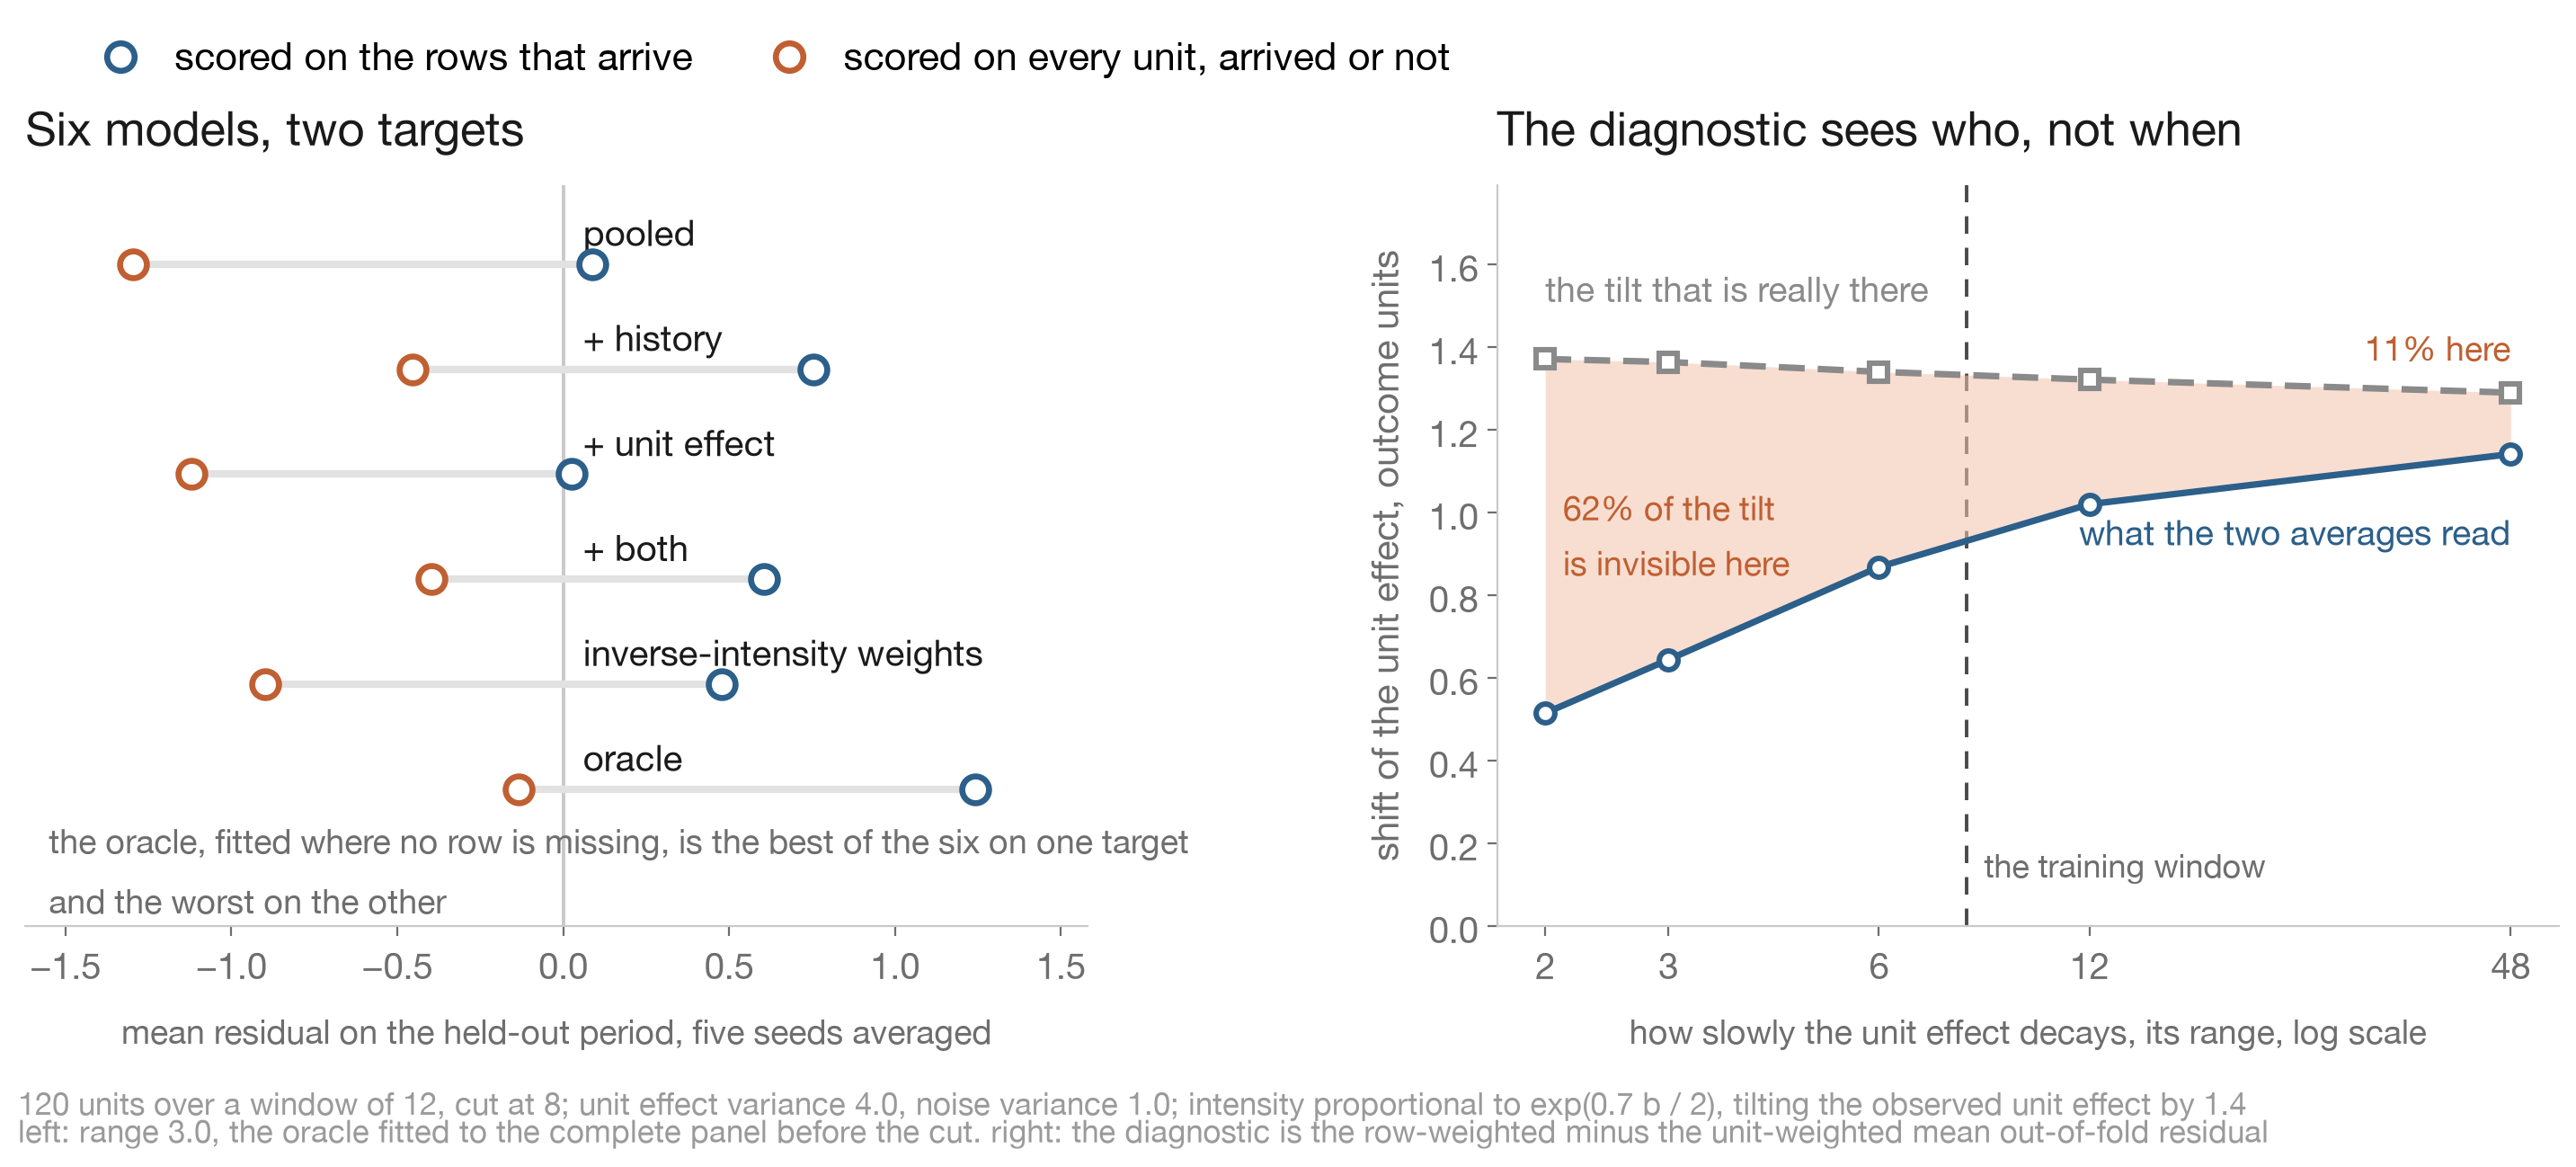

In [17]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
BLUE_E = "#2C5F8A"
CORAL_E, CORAL_F = "#C05F32", "#F4C3AC"
GREY_E, GREY_F = "#8a8a8a", "#E2E2E2"
INK, MUTED, FAINT = "#1a1a1a", "#6e6e6e", "#9a9a9a"

fig, axes = plt.subplots(1, 2, figsize=(14.4, 6.4), dpi=200)
fig.patch.set_facecolor("white")

# left: the same fitted model, scored on the two targets, one row per rung
ax = axes[0]
b = LD.pivot_table(index="rung", columns="target", values="bias").reindex(RUNGS)
y = np.arange(len(b))[::-1]
ax.axvline(0.0, color="#c9c9c9", lw=1.4, zorder=2)
for yy, (arr, gr) in zip(y, b[["arriving", "grid"]].values):
    ax.plot([gr, arr], [yy]*2, color=GREY_F, lw=3.0, solid_capstyle="round", zorder=3)
ax.scatter(b.arriving.values, y, s=115, color="white", edgecolor=BLUE_E, lw=2.4, zorder=5)
ax.scatter(b["grid"].values, y, s=115, color="white", edgecolor=CORAL_E, lw=2.4, zorder=5)
LAB = {"IIW": "inverse-intensity weights"}       # room to spell it out here, unlike in a table
for yy, r in zip(y, b.index):
    ax.text(0.06, yy + 0.30, LAB.get(r, r), fontsize=14.5, color=INK, ha="left", va="center")
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_ylim(-1.30, len(b) - 0.25)
ax.set_xlim(-1.62, 1.58)
ax.set_xlabel("mean residual on the held-out period, five seeds averaged", fontsize=13.5,
              color=MUTED, labelpad=10)
ax.text(-1.55, -0.80, "the oracle, fitted where no row is missing, is the best of the six on "
        "one target\nand the worst on the other", fontsize=13.5, color=MUTED, va="center",
        ha="left", linespacing=1.45)
ax.set_title("Six models, two targets", fontsize=19, color=INK, pad=16, loc="left")

# right: the diagnostic against the tilt it is trying to measure, over the range of the unit effect
ax = axes[1]
g = S.groupby("range")[["diagnostic", "true tilt"]].mean()
x = g.index.values
ax.fill_between(x, g.diagnostic.values, g["true tilt"].values, color=CORAL_F, alpha=0.55, lw=0,
                zorder=2)
ax.plot(x, g["true tilt"].values, color=GREY_E, lw=2.6, ls=(0, (4, 2)), marker="s", ms=7.5,
        mfc="white", mew=2.2, zorder=4)
ax.plot(x, g.diagnostic.values, color=BLUE_E, lw=2.6, marker="o", ms=7.5, mfc="white", mew=2.2,
        zorder=4)
ax.set_xscale("log")
ax.set_xticks(x)
ax.set_xticklabels([f"{v:g}" for v in x])
ax.minorticks_off()
ax.axvline(T_CUT, color="#4a4a4a", lw=1.4, ls=(0, (5, 4)), zorder=1)
ax.text(T_CUT*1.06, 0.10, "the training window", fontsize=13, color=MUTED, va="bottom", ha="left")
v = S.groupby("range").visible.mean()      # the same mean of ratios the notebook prints
lo, hi = v.iloc[0], v.iloc[-1]
ax.text(x[0], g["true tilt"].iloc[0] + 0.12, "the tilt that is really there", fontsize=14,
        color=GREY_E, ha="left", va="bottom")
ax.text(x[-1], g.diagnostic.iloc[-1] - 0.14, "what the two averages read", fontsize=14,
        color=BLUE_E, ha="right", va="top")
ax.text(x[0]*1.06, (g.diagnostic.iloc[0] + g["true tilt"].iloc[0])/2,
        f"{1 - lo:.0%} of the tilt\nis invisible here", fontsize=13.5, color=CORAL_E, ha="left",
        va="center", linespacing=1.4)
ax.text(x[-1], g["true tilt"].iloc[-1] + 0.06, f"{1 - hi:.0%} here", fontsize=13.5, color=CORAL_E,
        ha="right", va="bottom")
ax.set_ylim(0, g["true tilt"].max() + 0.42)
ax.set_xlabel("how slowly the unit effect decays, its range, log scale", fontsize=13.5, color=MUTED, labelpad=10)
ax.set_ylabel("shift of the unit effect, outcome units", fontsize=15, color=MUTED, labelpad=9)
ax.set_title("The diagnostic sees who, not when", fontsize=19, color=INK, pad=16, loc="left")

for ax in axes:
    ax.tick_params(labelsize=14.5, colors=MUTED, length=4)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c9c9c9")

handles = [Line2D([], [], marker="o", color="white", mec=BLUE_E, mew=2.4, ms=11, ls=""),
           Line2D([], [], marker="o", color="white", mec=CORAL_E, mew=2.4, ms=11, ls="")]
fig.legend(handles, ["scored on the rows that arrive", "scored on every unit, arrived or not"],
           loc="upper center", ncol=2, frameon=False, fontsize=15.5, bbox_to_anchor=(0.30, 1.0),
           handlelength=1.2, columnspacing=1.9)
fig.text(0.008, 0.030, f"{NG} units over a window of {T_WIN:.0f}, cut at {T_CUT:.0f}; unit effect "
         f"variance {SU**2:.1f}, noise variance {SE**2:.1f}; intensity proportional to "
         f"exp({GAMMA} b / {SU:.0f}), tilting the observed unit effect by {GAMMA*SU:.1f}",
         fontsize=12.5, color=FAINT, ha="left")
fig.text(0.008, 0.006, "left: range 3.0, the oracle fitted to the complete panel before the cut. "
         "right: the diagnostic is the row-weighted minus the unit-weighted mean out-of-fold "
         "residual", fontsize=12.5, color=FAINT, ha="left")
fig.tight_layout(rect=[0, 0.062, 1, 0.935])
fig.savefig("panel_informative_arrival.png", facecolor="white")
plt.show()

## What this notebook measured

Informative arrival is not a bias, it is a bias with respect to a target. The same fitted model,
scored on the rows the arrival process hands you and on every unit on a grid, gives two numbers
that differ by a factor of several, and the smaller of the two is the one a held-out set reports.
The clearest form of that blindness is what the held-out target does to the reference model: the
oracle, fitted to the complete latent panel, has the worst RMSE of the six rungs on the rows that
arrive, in both settings where arrival is informative, and the best on the grid. Held-out loss on
arriving rows ranks the two history rungs first, which is right, and inverts the rest.

Two limits worth stating. Every number here comes from one tilt strength, and the tilt sets both the
size of the problem and the power of the remedy, since a unit's arrival rate is a direct proxy for
the quantity the intensity depends on. And the history columns are evaluated past their training
range on both targets, because a gap has nothing after the cut to shorten it, which is where a tree
flattens rather than extrapolates.

The diagnostic costs two averages and reads zero when arrival is informative only through a feature
the model already uses, which is the case that a test on the raw outcome cannot separate: that test
fires under MAR-x on every seed, and so does the same diagnostic once x0 is dropped from the model.
It sees
the between-unit part of the tilt, and what share of the tilt that is has a closed form: the
variance share of a unit's average over the window, which the shape of part 6's variogram tells you
without having to trust a fitted range.

On the remedies, the cheap rungs do most of the work. Weighting is the rung that disappoints twice,
once through the effective sample size it costs on every target, and once because what it corrects
is a marginal, and a flexible model on slowly moving features has already learned something a
marginal does not describe.

What none of this settles is the mechanism. Every model in which arrival depends on the outcome has
a counterpart in which it depends only on the observed history, fitting the observed rows equally
well and disagreeing about the rows you never see; that is Molenberghs, Beunckens, Sotto and Kenward
(2008). For the targets you cannot observe, the honest output is a band with the assumption that
fixed it written next to it.

Where this sits in the literature: the two targets are the observation-level and unit-level
estimands of the informative cluster size work (Hoffman, Sen and Weinberg 2001; Williamson, Datta
and Satten 2003), the split between who arrives and when they arrive is that literature against
outcome-dependent follow-up, and inverse-intensity weighting is Lin, Scharfstein and Rosenheck
(2004), reviewed with the rest of the irregular-longitudinal toolkit by Pullenayegum and Lim (2016).
The vanishing effect of importance weights at high capacity is Byrd and Lipton (2019).